In [1]:


from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    exclude_subjects=["01", "07", "09", "12"],
    tr=2.1,
    task="sleep",
    load_signal=True,
    desc_add="clean-with-fd-clamped",
)


EOG data not full for 18, 1 (0/427). Skipping
EOG data not full for 18, 2 (0/427). Skipping
EOG data not full for 18, 3 (0/427). Skipping
EOG data not full for 18, 4 (0/427). Skipping
EOG data not full for 18, 5 (0/427). Skipping
EOG data not full for 16, 1 (282/427). Skipping
EOG data not full for 16, 2 (282/427). Skipping
EOG data not full for 16, 3 (293/427). Skipping
EOG data not full for 16, 4 (234/427). Skipping
EOG data not full for 16, 5 (237/427). Skipping
EOG data not full for 11, 5 (161/427). Skipping
EOG data not full for 23, 2 (0/427). Skipping
EOG data not full for 23, 3 (0/427). Skipping
EOG data not full for 15, 3 (151/427). Skipping


In [2]:
import numpy as np

def create_blocks(arr, trim: int):
    # Get indices where values are not NaN
    valid = ~np.isnan(arr)
    # Find contiguous blocks
    changes = np.diff(valid.astype(int))
    block_starts = np.where(changes == 1)[0] + 1
    block_ends = np.where(changes == -1)[0] + 1
    
    # Handle edge cases where array starts/ends with valid values
    if valid[0]:
        block_starts = np.concatenate([[0], block_starts])
    if valid[-1]:
        block_ends = np.concatenate([block_ends, [len(arr)]])
    
    blocks = [arr[s+trim:e-trim] for s, e in zip(block_starts, block_ends) 
          if (e - trim) - (s + trim) > 0]
    return blocks


def permute_labels(blocks):
    labels = [l for _, l in blocks]
    np.random.shuffle(labels)
    return [(b, l) for (b, _), l in zip(blocks, labels)]


In [23]:
from scipy.stats import zscore

l1 = "W"
l2 = "S"

subject_blocks = {}
for subject in mrio.subjects:
    blocks = []
    
    # For each run, get contiguous sleep and wake blocks,
    # trimming the edge TRs off
    for _, run, run_df in mrio.iter_run_events(subject=subject):
        eye_signal = run_df["mreyemove"]
        wake = np.full_like(eye_signal, np.nan)
        wake[run_df[l1]] = eye_signal[run_df[l1]]
        for block in create_blocks(wake, trim=1):
            blocks.append((block, l1))
        
        sleep = np.full_like(eye_signal, np.nan)
        sleep[run_df[l2]] = eye_signal[run_df[l2]]
        for block in create_blocks(sleep, trim=1):
            blocks.append((block, l2))
    
    subject_blocks[subject] = blocks
        
subject_blocks = {
    s: blocks for s, blocks in subject_blocks.items()
    if any(l == l2 for _, l in blocks)  
}
    

In [15]:

l1 = "W"
l2 = "1"
l3 = "2"

subject_blocks_three_state = {}
for subject in mrio.subjects:
    blocks = []
    
    # For each run, get contiguous sleep and wake blocks,
    # trimming the edge TRs off
    for _, run, run_df in mrio.iter_run_events(subject=subject):
        eye_signal = run_df["mreyemove"]
        one = np.full_like(eye_signal, np.nan)
        one[run_df[l1]] = eye_signal[run_df[l1]]
        for block in create_blocks(one, trim=1):
            blocks.append((block, l1))
        
        two = np.full_like(eye_signal, np.nan)
        two[run_df[l2]] = eye_signal[run_df[l2]]
        for block in create_blocks(two, trim=1):
            blocks.append((block, l2))
            
        three = np.full_like(eye_signal, np.nan)
        three[run_df[l3]] = eye_signal[run_df[l3]]
        for block in create_blocks(three, trim=1):
            blocks.append((block, l3))
    
    subject_blocks_three_state[subject] = blocks
        
subject_blocks_three_state = {
    s: blocks for s, blocks in subject_blocks_three_state.items()
    if any(l == l1 for _, l in blocks) 
    and any(l == l2 for _, l in blocks) 
    and any(l == l3 for _, l in blocks)
}
print(f"Subjects with all three states: {len(subject_blocks_three_state)}/{len(mrio.subjects)}")

Subjects with all three states: 20/27


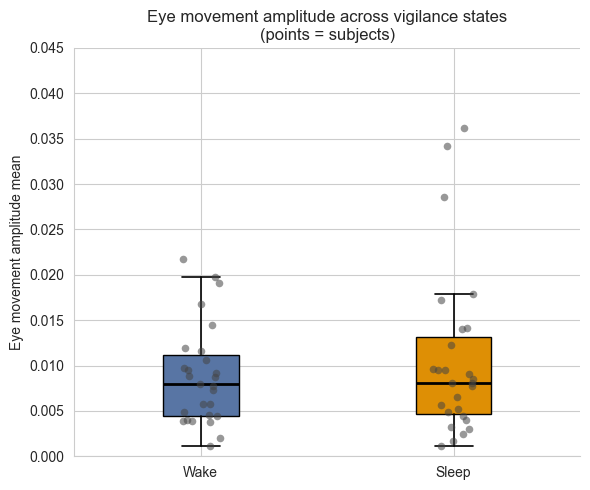

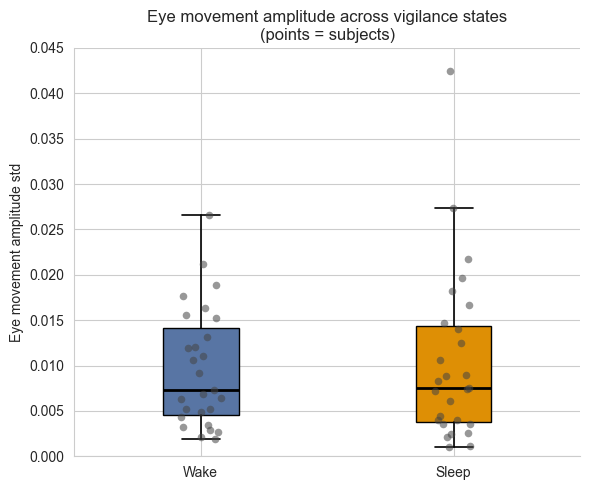

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

def get_state_values(subject_blocks, label, stat):
    subjects = list(subject_blocks.keys())
    result = []
    for s in subjects:
        blocks = [b for b, l in subject_blocks[s] if l == label]
        if len(blocks) > 0:
            result.append((s, stat(np.concatenate(blocks))))
        else:
            result.append((s, np.nan))
    return result  # list of (subject, value) tuples, nan if no data


states = {"W": "Wake", "S": "Sleep"}
colors = {"W": "#5875a4ff", "S": "#de8f05ff"}

for stat, desc in zip([np.mean, np.std], ["mean", "std"]):
    # Compute per-subject mean for each state
    state_values = {}
    for label in states:
        state_values[label] = {s: v for s, v in get_state_values(subject_blocks, label, stat)}
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Boxplots
    bp = ax.boxplot(
        [np.array([v for v in state_values[l].values() if not np.isnan(v)]) for l in states],
        positions=range(2),
        widths=0.3,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=4, alpha=0.5),
        zorder=2
    )
    
    for patch, label in zip(bp['boxes'], states):
        patch.set_facecolor(colors[label])
        patch.set_alpha(1)
    
    # Per-subject lines
    # subjects = list(subject_blocks_three_state.keys())
    # for subject in subjects:
    #     vals = [(j, state_values[l][subject]) for j, l in enumerate(states) 
    #             if not np.isnan(state_values[l][subject])]
    #     if len(vals) > 1:
    #         positions, values = zip(*vals)
    #         ax.plot(positions, values, color="gray", alpha=0.2, linewidth=0.8, zorder=1)
    
    # Jittered subject points
    for j, label in enumerate(states):
        valid = np.array([v for v in state_values[label].values() if not np.isnan(v)])
        jitter = np.random.uniform(-0.08, 0.08, len(valid))
        ax.scatter(
            np.full(len(valid), j) + jitter,
            valid,
            color="#4444448c", alpha=0.55, s=30, zorder=3,
            edgecolors='white', linewidths=0
        )
    
    ax.set_xticks(range(2))
    ax.set_xticklabels(states.values())
    ax.set_ylabel(f"Eye movement amplitude {desc}")
    ax.set_title("Eye movement amplitude across vigilance states\n(points = subjects)")
    ax.set_ylim(0,0.045)
    ax.spines[["top", "right"]].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    fig.savefig(f"/Users/zach/2025_RA/matthias/final images/eye_voxels/{desc}_amplitude_states.svg", dpi=300)


In [20]:
state_values["1"]

{'10': 0.002590767997577912,
 '22': 0.009650967707935458,
 '06': 0.029499410749208775,
 '18': 0.012417191118983454,
 '25': 0.0011451716859720233,
 '17': 0.008722207802605266,
 '33': 0.0068997518016486,
 '19': 0.009218452596746406,
 '24': 0.008681439737387161,
 '16': 0.008192567672560777,
 '32': 0.003966308955601666,
 '08': 0.01789288645240233,
 '11': 0.014093274118757403,
 '23': 0.005375845122226834,
 '26': 0.036206898437123644,
 '30': 0.004614467423960827,
 '14': 0.009623525687380974,
 '29': 0.01722594485208794,
 '13': 0.03424293833554806,
 '05': 0.00392500532150005,
 '04': 0.009714075703381475,
 '20': 0.005665993488943696,
 '27': 0.009318891715818824,
 '03': 0.005687322098186317,
 '31': 0.01657218507140831,
 '15': 0.0019184325000459392,
 '28': 0.003331779652835682}

In [36]:
from scipy.stats import f_oneway
from scipy.stats import ttest_1samp

from scipy.stats import zscore
import numpy as np

    
    

def compute_f_statistic(blocks):
    wake = np.concatenate([b for b, l in blocks if l == "W"])
    n1   = np.concatenate([b for b, l in blocks if l == "1"])
    n2   = np.concatenate([b for b, l in blocks if l == "2"])
    # Skip subjects missing a state
    if len(wake) == 0 or len(n1) == 0 or len(n2) == 0:
        return np.nan
    return f_oneway(wake, n1, n2).statistic

def permutation_f_test_pseudoz(subject_blocks, n_permutations=10000):
    subjects = list(subject_blocks.keys())
    
    subject_zs = []
    for subject in subjects:
        blocks = subject_blocks[subject]
        
        observed_f = compute_f_statistic(blocks)
        if np.isnan(observed_f):
            continue
        
        null_fs = [compute_f_statistic(permute_labels(blocks)) 
                   for _ in range(n_permutations)]
        
        null_mean = np.mean(null_fs)
        null_std = np.std(null_fs)
        subject_zs.append((observed_f - null_mean) / null_std)
    
    subject_zs = np.array(subject_zs)
    t_stat, p_value = ttest_1samp(subject_zs, popmean=0)
    
    return {
        "subject_zs": subject_zs,
        "group_z": np.mean(subject_zs),
        "t_stat": t_stat,
        "p_value": p_value
    }

results_f = permutation_f_test_pseudoz(subject_blocks_three_state)
print(f"t = {results_f['t_stat']:.4f}, p = {results_f['p_value']:.4f}")

t = 1.8572, p = 0.0788


In [55]:

from scipy.stats import zscore

l1 = "1"
l2 = "2"

subject_blocks = {}
for subject in mrio.subjects:
    blocks = []
    
    # For each run, get contiguous sleep and wake blocks,
    # trimming the edge TRs off
    for _, run, run_df in mrio.iter_run_events(subject=subject):
        eye_signal = run_df["mreyemove"]
        wake = np.full_like(eye_signal, np.nan)
        wake[run_df[l1]] = eye_signal[run_df[l1]]
        for block in create_blocks(wake, trim=1):
            blocks.append((block, l1))
        
        sleep = np.full_like(eye_signal, np.nan)
        sleep[run_df[l2]] = eye_signal[run_df[l2]]
        for block in create_blocks(sleep, trim=1):
            blocks.append((block, l2))
    
    subject_blocks[subject] = blocks
        
subject_blocks = {
    s: blocks for s, blocks in subject_blocks.items()
    if any(l == l2 for _, l in blocks)  
}
    

def compute_statistic(blocks, stat, l1, l2):
    """
    Compute statistic per subject
    Find the difference in descriptors for each state using all 
    contiguous state blocks across runs 
    Parameters
    ----------
    blocks
    stat

    Returns
    -------

    """
    wake_vals = np.concatenate([b for b, l in blocks if l == l1])
    sleep_vals = np.concatenate([b for b, l in blocks if l == l2])
    if stat == "mean":
        return np.mean(wake_vals) - np.mean(sleep_vals)
    elif stat == "var":
        return np.var(wake_vals) - np.var(sleep_vals)
    elif stat == "median":
        return np.median(wake_vals) - np.median(sleep_vals)
    elif stat == "iqr":
        return np.percentile(wake_vals, 75) - np.percentile(sleep_vals, 25)

def permutation_test2(subject_blocks, stat, n_permutations=10000):
    subjects = list(subject_blocks.keys())
    
    subj_zs = []
    for subject in subjects:
        subj_null_distribution = []
        for _ in range(n_permutations):
            perm_stats = np.array([
                compute_statistic(permute_labels(subject_blocks[subject]), stat, l1, l2) 
            ])
            subj_null_distribution.append(np.mean(perm_stats))
        shuffled_mean = np.mean(subj_null_distribution)
        shuffled_std = np.std(subj_null_distribution)
        observed_mean = compute_statistic(subject_blocks[subject], stat, l1, l2)
        
        subj_z = (observed_mean - shuffled_mean) / shuffled_std
        subj_zs.append(subj_z)
    return np.mean(subj_zs), subj_zs


from scipy.stats import f_oneway

# Run tests
# results_mean = permutation_test(subject_blocks, stat="mean", n_permutations=10000)
# results_median = permutation_test(subject_blocks, stat="median", n_permutations=10000)
# results_var  = permutation_test(subject_blocks, stat="var", n_permutations=10000)

mean_zs, zs  = permutation_test2(subject_blocks, stat="var", n_permutations=10000)


In [56]:

from scipy.stats import ttest_1samp

ttest_1samp(zs, 0, alternative="two-sided"), mean_zs
# print(f"t = {ttest.statistic:.4f}, p = {ttest.pvalue:.4f}")

# print(f"{mean_zs:.4f}")
# print(zs)

(TtestResult(statistic=1.8343822155313312, pvalue=0.0823069529268251, df=19),
 0.4775371624139656)

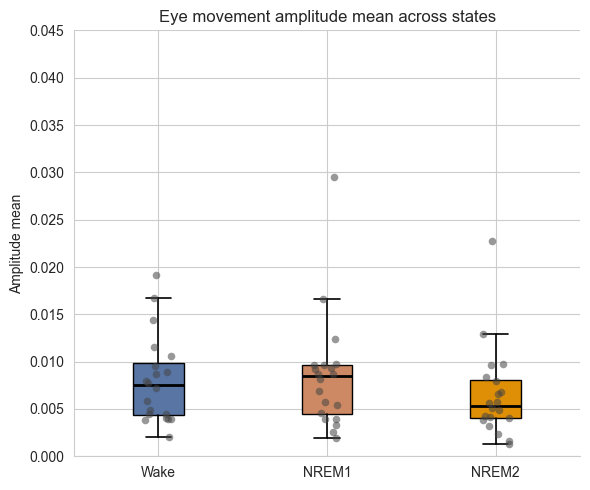

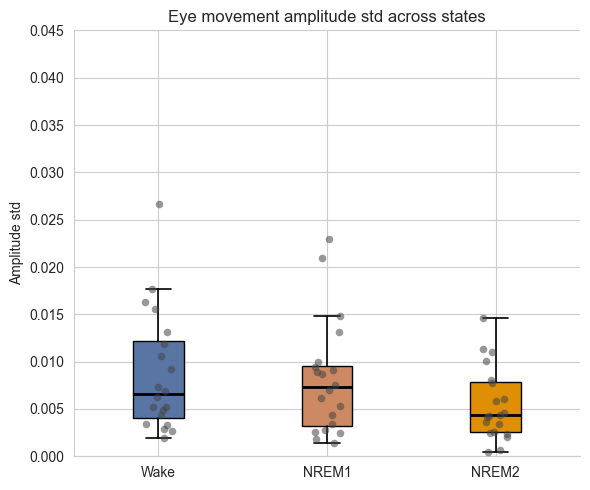

In [11]:



  import matplotlib.pyplot as plt
  import numpy as np

  states_three = {"W": "Wake", "1": "NREM1", "2": "NREM2"}
  colors_three = {"W": "#5875a4ff", "1": "#cc8963ff", "2": "#de8f05ff"}

  for stat_fn, desc in [(np.mean, "mean"), (np.std, "std")]:
      state_values = {}
      for label in states_three:
          state_values[label] = {
              s: stat_fn(np.concatenate([b for b, l in subject_blocks_three_state[s] if l == label]))
              for s in subject_blocks_three_state
              if any(l == label for _, l in subject_blocks_three_state[s])
          }

      fig, ax = plt.subplots(figsize=(6, 5))

      positions = list(range(len(states_three)))
      labels = list(states_three.keys())

      bp = ax.boxplot(
          [np.array([v for v in state_values[l].values() if not np.isnan(v)]) for l in labels],
          positions=positions,
          widths=0.3,
          patch_artist=True,
          showfliers=False,
          medianprops=dict(color='black', linewidth=2),
          whiskerprops=dict(linewidth=1.2),
          capprops=dict(linewidth=1.2),
          zorder=2,
      )

      for patch, label in zip(bp['boxes'], labels):
          patch.set_facecolor(colors_three[label])
          patch.set_alpha(1)

      for j, label in enumerate(labels):
          valid = np.array([v for v in state_values[label].values() if not np.isnan(v)])
          jitter = np.random.uniform(-0.08, 0.08, len(valid))
          ax.scatter(
              np.full(len(valid), j) + jitter,
              valid,
              color="#4444448c", alpha=0.55, s=30, zorder=3,
              edgecolors='white', linewidths=0,
          )

      ax.set_xticks(positions)
      ax.set_xticklabels(states_three.values())
      ax.set_ylabel(f"Amplitude {desc}")
      ax.set_ylim(0, 0.045)
      ax.spines[["top", "right"]].set_visible(False)
      ax.set_title(f"Eye movement amplitude {desc} across states")

      plt.tight_layout()
      plt.show()
      fig.savefig(f"/Users/zach/2025_RA/matthias/final images/eye_voxels/{desc}_amplitude_three_states.svg", dpi=300)



In [67]:

print(f"Mean amplitude: {l1}-{l2} = {results_mean['observed_group']:.4f}, p = {results_mean['p_value']:.4f}")
print(f"Variance:      {l1}-{l2} = {results_var['observed_group']:.4f},  p = {results_var['p_value']:.4f}")
print(f"Median:       {l1}-{l2} = {results_median['observed_group']:.4f},  p = {results_median['p_value']:.4f}")

Mean amplitude: W-1 = -0.0021, p = 0.0003
Variance:      W-1 = -0.0001,  p = 0.0064
Median:       W-1 = -0.0021,  p = 0.0000


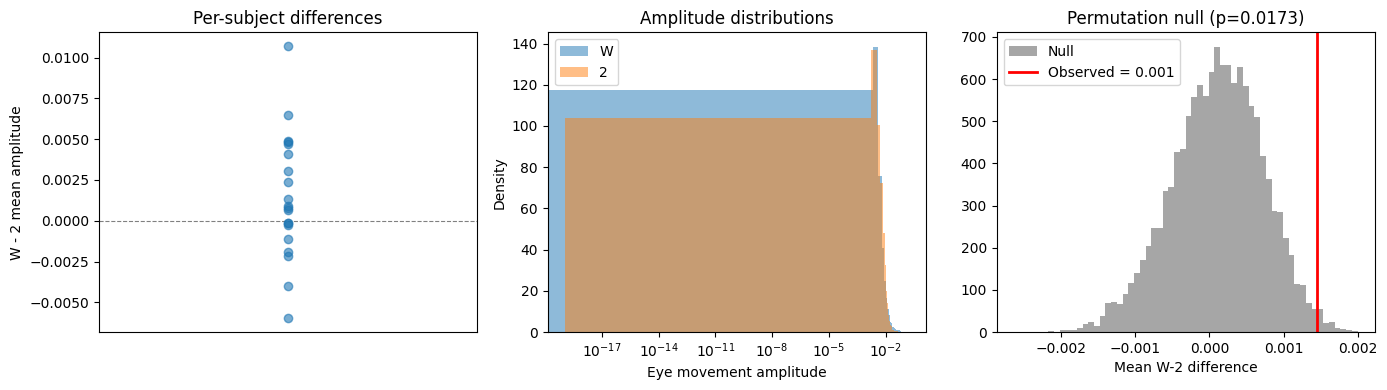

In [64]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

stat = "mean"
result = results_mean


# 1. Per-subject W-S mean differences (paired)
subjects = list(subject_blocks.keys())
per_subject = np.array([compute_statistic(subject_blocks[s], stat) for s in subjects])

axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].plot(np.zeros(len(per_subject)), per_subject, 'o', alpha=0.6)
axes[0].set_xticks([])
axes[0].set_ylabel(f"{l1} - {l2} {stat} amplitude")
axes[0].set_title("Per-subject differences")

# 2. Distribution of pooled wake vs sleep values across all subjects
all_wake = np.concatenate([
    np.concatenate([b for b, l in subject_blocks[s] if l == l1]) for s in subjects
])
all_sleep = np.concatenate([
    np.concatenate([b for b, l in subject_blocks[s] if l == l2]) for s in subjects
])

axes[1].hist(all_wake, bins=80, alpha=0.5, label=l1, density=True)
axes[1].hist(all_sleep, bins=80, alpha=0.5, label=l2, density=True)
axes[1].set_xlabel("Eye movement amplitude")
axes[1].set_ylabel("Density")
axes[1].set_title("Amplitude distributions")
# axes[1].set_xscale('log')
axes[1].legend()

# 3. Null distribution with observed statistic
axes[2].hist(result["null_distribution"], bins=60, density=True, 
             color='gray', alpha=0.7, label="Null")
axes[2].axvline(result["observed_group"], color='red', 
                linewidth=2, label=f"Observed = {result['observed_group']:.3f}")
axes[2].set_xlabel(f"{stat.capitalize()} {l1}-{l2} difference")
axes[2].set_title(f"Permutation null (p={result['p_value']:.4f})")
axes[2].legend()

plt.tight_layout()
plt.show()

In [70]:
subjects = list(subject_blocks.keys())
all_wake = np.concatenate([np.concatenate([b for b, l in subject_blocks[s] if l == l1]) for s in subjects])
all_sleep = np.concatenate([np.concatenate([b for b, l in subject_blocks[s] if l == l2]) for s in subjects])

print(f"{l1} mean: {np.mean(all_wake):.4f}, {l2} mean: {np.mean(all_sleep):.4f}")
print(f"{l1} median: {np.median(all_wake):.4f}, {l2} median: {np.median(all_sleep):.4f}")
print(f"{l1} var: {np.var(all_wake):.6f}, {l2} var: {np.var(all_sleep):.6f}")

W mean: 0.0091, 1 mean: 0.0084
W median: 0.0046, 1 median: 0.0051
W var: 0.000184, 1 var: 0.000141


In [122]:
mrio.load
for label, state_name in states.items():
    block_lengths = [
        len(b) for s in subject_blocks_three_state
        for b, l in subject_blocks_three_state[s]
        if l == label and len(b) >= min_block_len
    ]
    print(f"{state_name}: n_blocks={len(block_lengths)}, "
          f"mean_length={np.mean(block_lengths):.1f}, "
          f"median_length={np.median(block_lengths):.1f}")
    

Wake: n_blocks=164, mean_length=119.1, median_length=55.0
1: n_blocks=239, mean_length=64.7, median_length=41.0
2: n_blocks=125, mean_length=89.5, median_length=56.0
